In [11]:
# Standard Libraries
import math
import pickle
import random
import numpy as np

# Data Manipulation and Visualization
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm import tqdm

# Quantum Computing
import pennylane as qml

# Deep Learning
import torch
from torch.autograd import Variable
from torchvision import datasets, transforms

# Utility Functions
from functools import reduce

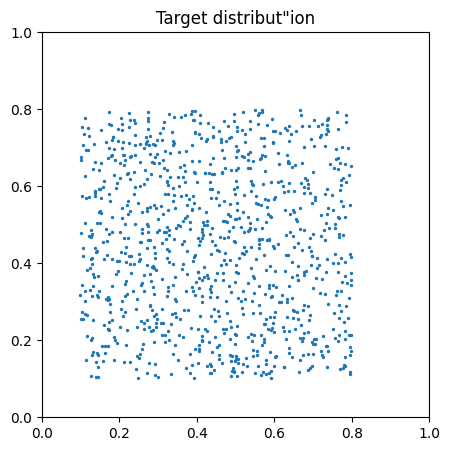

In [77]:
data_num = 1000
data_type = "biased_box2"
train_in = np.loadtxt(f'data/2D/{data_type}_{data_num}_1.txt') # 바로 점 데이터를 불러옴
plt.figure(figsize=(5,5))
plt.scatter(train_in[:,0], train_in[:,1], s=2.0)
plt.title('Target distribut"ion')
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.show()

In [78]:
# setting torch device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [79]:
noise_qubits = 3
code_qubits = 2
n_qubits = noise_qubits + code_qubits
output_qubits = 2
assert(output_qubits <= noise_qubits) # 출력 큐빗은 noise qubit이하여야 한다.

n_layers = 5
BATCH_SIZE = 16
print("n_qubits = {} n_layers = {}".format(n_qubits, n_layers))

dev = qml.device("default.qubit", wires=n_qubits)
# dev = qml.device("ionq.simulator", wires=2)
# dev = qml.device("ionq.qpu", wires=2)

n_qubits = 5 n_layers = 5


모델들 불러오기

In [80]:
import importlib
import matplotlib.pyplot as plt
from modules import QGAN, Discriminator, MINE  # 초기 import
importlib.reload(QGAN)  # 모듈 갱신
importlib.reload(Discriminator)  # 모듈 갱신
importlib.reload(MINE)  # 모듈 갱신

# 생성자 파라미터 초기화 및 모듈 불러오기
generator_initial_params = Variable(torch.tensor(np.random.normal(-np.pi/2 , np.pi/2, (n_layers, n_qubits, 3))), requires_grad=True)
generator = QGAN.QGAN(n_qubits, output_qubits, n_layers, generator_initial_params, dev)

# 판별자, MINE 초기화
discriminator = Discriminator.LinearDiscriminator(input_dim = output_qubits)
mine = MINE.LinearMine(code_qubits=code_qubits, output_qubits=output_qubits)

In [81]:
G_lr = 0.001
D_lr = 0.0003
M_lr = 0.001
coeff = 0.1

use_mine = False
G_opt = torch.optim.Adam([generator.params], lr=G_lr)
D_opt = torch.optim.Adam(discriminator.parameters(), lr=D_lr)
M_opt = torch.optim.Adam(mine.parameters(), lr=M_lr)

# G_scheduler = torch.optim.lr_scheduler.StepLR(G_opt, step_size=30, gamma=0.85)
# D_scheduler = torch.optim.lr_scheduler.StepLR(D_opt, step_size=30, gamma=0.85)
# M_scheduler = torch.optim.lr_scheduler.StepLR(M_opt, step_size=30, gamma=0.85)

학습에 사용할 train_step과 disc_cost_fn 정의 

In [82]:
import torch.nn as nn

def bitwise_sums(arr):
    n = len(arr).bit_length() - 1  # 비트 길이를 계산하여 반복 횟수를 정함
    sums = torch.zeros(n, dtype=arr.dtype, device=arr.device)  # 결과를 저장할 텐서
    for bit in range(n):
        # 조건에 맞는 인덱스 선택을 위해 i-th 비트를 검사
        mask = (torch.arange(len(arr), device=arr.device) >> bit) & 1
        sums[bit] = arr[mask.bool()].sum()  # 조건에 맞는 원소들의 합산
    return sums

def output_postprocessing(arr):
    # arr: (BATCH_SIZE, output_qubits**2)
    # return: (BATCH_SIZE, output_qubits)
    ret = torch.stack([bitwise_sums(arr[i]) for i in range(len(arr))])
    return ret


def generator_train_step(generator_input, use_mine = False):
    '''
    params (torch.Tensor(레이어,큐빗,3)): a parameter
    generator_input (torch.Tensor(BATCH_SIZE, n_qubits)): 생성기 입력 seed (noise + code). -1~1 사이의 값
    '''
    code_input = generator_input[:, -code_qubits:] # 입력중에서 code만 뽑는다. (BATCH_SIZE, code_qubits)

    generator_output = generator.forward(generator_input) # 출력을 뽑아낸다 (BATCH_SIZE, output_qubits**2)
    generator_output = output_postprocessing(generator_output) # (BATCH_SIZE, output_qubits)

    generator_output = generator_output.to(torch.float32) # (BATCH_SIZE, output_qubits)
    
    disc_output = discriminator(generator_output) # 밑에 코드에서 정의됨
    gan_loss = torch.log(1-disc_output).mean()
    
    if use_mine:
        pred_xy = mine(code_input, generator_output)
        code_input_shuffle = code_input[torch.randperm(BATCH_SIZE)]
        pred_x_y = mine(code_input_shuffle, generator_output)
        mi = torch.mean(pred_xy) - torch.log(torch.mean(torch.exp(pred_x_y)))
        gan_loss -= coeff * mi

    return generator_output, gan_loss# TODO: 이건 분석용으로 넣어놓음.지워야 함.

disc_loss_fn = nn.BCELoss()
def disc_cost_fn(real_input, fake_input, smoothing=False):
    batch_num = real_input.shape[0]

    disc_real = discriminator(real_input)
    disc_fake = discriminator(fake_input)

    real_label = torch.ones((batch_num, 1)).to(device)
    fake_label = torch.zeros((batch_num, 1)).to(device)
    
    if smoothing:
        real_label = real_label - 0.2*torch.rand(real_label.shape).to(device)
    
    loss = 0.5 * (disc_loss_fn(disc_real, real_label) + disc_loss_fn(disc_fake, fake_label))
    
    return loss

In [83]:
def visualize_output_simple(log_gen_outputs, log_gen_codes, epoch, writer, image_file_path):
    # 1. 첫 번째 플롯: log_gen_outputs의 2차원 점 분포
    fig1, ax1 = plt.subplots(figsize=(6, 6))
    ax1.scatter(log_gen_outputs[:, 0], log_gen_outputs[:, 1], s=10, alpha=0.5)
    ax1.set_title(f'Epoch {epoch} - 2D Distribution')
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.grid()

    # 2. 두 번째 플롯: log_gen_codes의 첫 번째 열을 색상으로 사용
    fig2, ax2 = plt.subplots(figsize=(6, 6))
    scatter2 = ax2.scatter(log_gen_outputs[:, 0], log_gen_outputs[:, 1], s=10, c=log_gen_codes[:, 0], cmap='RdYlBu', alpha=0.5)
    ax2.set_title(f'Epoch {epoch} - Code 1 Color')
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.grid()
    fig2.colorbar(scatter2, ax=ax2)  # 색상 막대 추가

    # 3. 세 번째 플롯: log_gen_codes의 두 번째 열을 색상으로 사용
    fig3, ax3 = plt.subplots(figsize=(6, 6))
    scatter3 = ax3.scatter(log_gen_outputs[:, 0], log_gen_outputs[:, 1], s=10, c=log_gen_codes[:, 1], cmap='RdYlBu', alpha=0.5)
    ax3.set_title(f'Epoch {epoch} - Code 2 Color')
    ax3.set_xlim(0, 1)
    ax3.set_ylim(0, 1)
    ax3.grid()
    fig3.colorbar(scatter3, ax=ax3)  # 색상 막대 추가

    # TensorBoard에 기록
    writer.add_figure(f'2D Distribution', fig1, epoch)
    writer.add_figure(f'Code 1 Color', fig2, epoch)
    writer.add_figure(f'Code 2 Color', fig3, epoch)

    # fig1, fig2, fig3 를 image file로 저장
    fig1.savefig(f'{image_file_path}/dist_epoch_{epoch}.png')
    fig2.savefig(f'{image_file_path}/code1_epoch_{epoch}.png')
    fig3.savefig(f'{image_file_path}/code2_epoch_{epoch}.png')

    # 메모리 관리를 위해 plt를 닫음
    plt.close(fig1)
    plt.close(fig2)
    plt.close(fig3)

In [ ]:
from torch.utils.tensorboard import SummaryWriter
import ndtest # 2D 분포 검정에 사용
from datetime import datetime
import os
import time
from modules.utils import convert_ipynb_to_html # 현재 html파일 저장을 위해 사용

current_time = datetime.now().strftime("%b%d_%H-%M")  # "Aug13_14-12" 형식
save_dir = f"./runs/{data_type}_{data_num}_{use_mine}_{current_time}"
scalar_save_path = os.path.join(save_dir, f"{data_type}_{data_num}_{use_mine}_{current_time}.csv")
image_save_dir = os.path.join(save_dir, "images")
numpy_save_dir = os.path.join(save_dir, "numpy")
os.makedirs(image_save_dir, exist_ok=True)
os.makedirs(numpy_save_dir, exist_ok=True)

convert_ipynb_to_html('2D_train.ipynb', os.path.join(save_dir, "2D_train.html"))

# CSV 파일 초기화 (헤더 작성)
if not os.path.exists(scalar_save_path):
    df = pd.DataFrame(columns=['epoch', 'D_loss', 'G_loss', 'MI', 'D_ks', 'p_value', 'angle', 'time'] + 
                  [f'Corr/code{i}-{axis}' for i in range(code_qubits) for axis in ['x', 'y']])

# TensorBoard SummaryWriter 초기화
writer = SummaryWriter(log_dir=save_dir)

epoch_num = 300
start_time = time.time()

for epoch in range(1, epoch_num+1):
    G_loss_sum = 0.0
    D_loss_sum = 0.0
    mi_sum = 0.0
    batch_num = len(train_in) // BATCH_SIZE
    pbar = tqdm(range(batch_num))

    # 그림 그릴때 필요하다
    gen_outputs = [] # (데이터수, 2) 생성한 모든 점의 좌표들
    gen_codes = [] # (데이터수, 2) 점 찍는데 들어간 code들

    for batch_idx in pbar:
        batch = torch.FloatTensor(train_in[BATCH_SIZE * batch_idx : BATCH_SIZE * batch_idx + BATCH_SIZE])

        # train generator
        generator_seed = torch.rand((BATCH_SIZE, n_qubits))*2-1
        generator_output, generator_loss = generator_train_step(generator_seed, use_mine=use_mine)
        G_opt.zero_grad()
        generator_loss.requires_grad_(True)
        generator_loss.backward()
        G_opt.step()
        
        # train discriminator
        fake_input = generator_output.detach().to(torch.float32)
        disc_loss = disc_cost_fn(batch, fake_input, smoothing=False)
        D_opt.zero_grad()
        disc_loss.requires_grad_(True)
        disc_loss.backward()
        D_opt.step()

        # train mine
        code_input = generator_seed[:, -code_qubits:] # (BATCH_SIZE, code_qubits) 코드만 추출
        pred_xy = mine(code_input, fake_input)
        code_input_shuffle = code_input[torch.randperm(BATCH_SIZE)]
        pred_x_y = mine(code_input_shuffle, fake_input)
        mi = -torch.mean(pred_xy) + torch.log(torch.mean(torch.exp(pred_x_y)))
        M_opt.zero_grad()
        mi.requires_grad_(True)
        mi.backward()
        M_opt.step()

        D_loss_sum += disc_loss.item()
        G_loss_sum += generator_loss.item()
        mi_sum -= mi.item() # (-1)곱해져 있어서 빼야함.

        gen_outputs.append(fake_input.numpy())
        gen_codes.append(code_input.numpy())

        pbar.set_postfix({'G_loss': G_loss_sum/(batch_idx+1), 'D_loss': D_loss_sum/(batch_idx+1), 'MI': mi_sum/(batch_idx+1)})

    # G_scheduler.step()
    # D_scheduler.step()
    # M_scheduler.step()
    
    gen_outputs = np.concatenate(gen_outputs, axis=0) # (train_num, 2)
    gen_codes = np.concatenate(gen_codes, axis=0) # (train_num, 2)

    D_loss, G_loss, mi = D_loss_sum/batch_num, G_loss_sum/batch_num, mi_sum/batch_num
    p_value, D_ks = ndtest.ks2d2s(gen_outputs[:, 0], gen_outputs[:, 1], train_in[:, 0], train_in[:, 1], extra=True)

    writer.add_scalar('Loss/d_loss', D_loss, epoch)
    writer.add_scalar('Loss/g_loss', G_loss, epoch)
    writer.add_scalar('Metrics/mi', mi, epoch)
    writer.add_scalar('Metrics/D_ks', D_ks, epoch)
    writer.add_scalar('Metrics/p_value', p_value, epoch)

    

    # code와 x, y의 상관관계를 측정 후 기록
    df = pd.DataFrame({'x': gen_outputs[:, 0], 'y': gen_outputs[:, 1]})
    for i in range(code_qubits):
        df[f'code{i}'] = gen_codes[:, i]
    corr_mat = df.corr().to_numpy()
    for i in range(code_qubits):
        writer.add_scalar(f'Corr/code{i}-x', corr_mat[0, i+2], epoch)
        writer.add_scalar(f'Corr/code{i}-y', corr_mat[1, i+2], epoch)

    # code0과 code1 사이의 각도 계산 (벡터의 내적 및 크기 사용)
    cos_theta = (corr_mat[0, 2] * corr_mat[0, 3] + corr_mat[1, 2] * corr_mat[1, 3]) / (
        np.sqrt(corr_mat[0, 2]**2 + corr_mat[1, 2]**2) * np.sqrt(corr_mat[0, 3]**2 + corr_mat[1, 3]**2)
    )
    theta_degrees = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))

    # 예각으로 변환
    theta_degrees = min(theta_degrees, 180 - theta_degrees)
    writer.add_scalar('Corr/angle', theta_degrees, epoch)


    # 스칼라 값 CSV로 덮어쓰기 저장
    file_exists = os.path.isfile(scalar_save_path)
    new_data = pd.DataFrame({
        'epoch': [epoch],
        'D_loss': [D_loss],
        'G_loss': [G_loss],
        'MI': [mi],
        'D_ks': [D_ks],
        'p_value': [p_value],
        'time': [int((time.time() - start_time)*1000)],
        **{f'Corr/code{i}-{axis}': [corr_mat[j, i+2]] for i in range(code_qubits) for j, axis in enumerate(['x', 'y'])},
        'angle': [theta_degrees]  # code0과 code1 사이의 예각 추가
    })

    new_data.to_csv(scalar_save_path, mode='a',  header=not file_exists)
    
    visualize_output_simple(gen_outputs, gen_codes, epoch, writer, image_save_dir) # save fig here

    # 각 epoch마다 numpy의 savetxt를 사용하여 저장
    output_file_path = os.path.join(numpy_save_dir, f"gen_outputs_epoch_{epoch}.txt")
    codes_file_path = os.path.join(numpy_save_dir, f"gen_codes_epoch_{epoch}.txt")

    np.savetxt(output_file_path, gen_outputs)
    np.savetxt(codes_file_path, gen_codes)
    
    #print("epoch: {}, D_loss: {}, G_loss: {}, MI = {}".format(epoch, D_loss, G_loss, mi))
    #print("좌표값 평균 = ", np.mean(gen_outputs[:,0]), np.mean(gen_outputs[:,1]), "디버그 =", generator.params[0][0][0].item())

HTML 파일이 ./runs/biased_box2_1000_False_Oct12_17-57\2D_train.html에 저장되었습니다.


 87%|████████▋ | 54/62 [00:56<00:09,  1.17s/it, G_loss=-.688, D_loss=0.692, MI=0.000125]